# Tri-Stream Multimodal Video Network for Deepfake Detection

This notebook implements a comprehensive Tri-Stream Multimodal architecture that combines:

**Stream 1 (Spatial Forensics - Full Image Module):** Complete Dual-Stream Image Detection Module (CLIP ViT-L/14 + SRM Noise Residual Stream) with temporal pooling across 15 frames.

**Stream 2 (Audio Forensics):** Dual-Feature CNN-GRU model extracting Mel + LFCC features from audio segments.

**Stream 3 (Cross-Modal Synchronization):** CLIP ViT-B/32 visual encoder + Lightweight CNN audio encoder + Multi-Head Cross-Attention + Bidirectional LSTM to detect audio-visual inconsistencies.

**Late Fusion:** Concatenate all three forensic vectors and pass through a classifier for final prediction.

**Label Mapping:** Fake = Class 0, Real = Class 1

**Workflow:**
1. Offline Feature Extraction with Robust MTCNN Cropping + Sanity Check Debug Grid
2. PyTorch Dataset with on-the-fly augmentation
3. Tri-Stream Architecture with differential learning rates
4. Training Loop with gradient clipping
5. Evaluation with inverted labels (Fake as positive class) for Precision/Recall/F1/AUC

In [1]:
import os
import sys
import warnings
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from transformers import CLIPVisionModel, CLIPModel, CLIPProcessor

import torchaudio
import librosa

from facenet_pytorch import MTCNN

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score
)

warnings.filterwarnings('ignore')

sys.path.append('..')
sys.path.append('../utils')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Using device: cuda
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA RTX 4000 Ada Generation
CUDA memory: 21.47 GB


## Step 1: Offline Feature Extraction with Robust MTCNN Cropping

This cell precomputes features from raw `.mp4` files:
- Sample 15 evenly spaced frames per video
- Use MTCNN for face detection with robust fallback logic
- Apply 15% bounding box expansion and manual cropping
- Save debug grids (horizontal concatenation of 15 cropped faces) for visual sanity check
- Extract corresponding audio segments
- Save tensors as `.pt` files for efficient loading during training

In [ ]:
def extract_video_features_with_robust_cropping(
    video_dir='../data/video',
    output_tensors_dir='../data/video_tensors',
    output_debug_dir='../data/debug_crops',
    num_frames=15,
    target_size=(224, 224),
    bbox_expansion=0.15,
    target_sr=16000,
    target_duration=4.0
):
    """
    Extract visual and audio features from videos with robust MTCNN face cropping.
    
    Robust Cropping Strategy:
    1. MTCNN Detection: Use boxes, probs = mtcnn.detect(frame)
    2. Temporal Fallback: If MTCNN fails, use last_good_box from previous frame
    3. Spatial Fallback: If first frame fails, use 50% center crop of the full frame
    4. Manual Cropping: Expand bounding box by 15%, clip to frame boundaries, crop and resize
    5. Debug Grid: Save horizontal concatenation of 15 cropped faces as .jpg
    
    Args:
        video_dir: Directory containing train/val/test/real/fake subdirectories with .mp4 files
        output_tensors_dir: Directory to save precomputed .pt tensors
        output_debug_dir: Directory to save debug crop visualizations
        num_frames: Number of frames to sample per video (default: 15)
        target_size: Target size for cropped faces (default: 224x224)
        bbox_expansion: Bounding box expansion factor (default: 0.15 = 15%)
        target_sr: Target audio sample rate (default: 16000 Hz)
        target_duration: Target audio duration (default: 4.0 seconds)
    """
    
    print("="*60)
    print("OFFLINE FEATURE EXTRACTION - TRI-STREAM VIDEO NETWORK")
    print("="*60)
    
    # Initialize MTCNN for face detection
    print("Initializing MTCNN face detector...")
    mtcnn = MTCNN(keep_all=False, device=device, post_process=False, select_largest=False)
    print(f"✓ MTCNN initialized on {device}")
    
    splits = ['train', 'val', 'test']
    labels = ['fake', 'real']
    
    for split in splits:
        for label in labels:
            print(f"\n{'='*60}")
            print(f"Processing {split}/{label}")
            print(f"{'='*60}")
            
            # Setup directories
            video_split_dir = Path(video_dir) / split / label
            output_tensor_split_dir = Path(output_tensors_dir) / split / label
            output_debug_split_dir = Path(output_debug_dir) / split / label
            
            output_tensor_split_dir.mkdir(parents=True, exist_ok=True)
            output_debug_split_dir.mkdir(parents=True, exist_ok=True)
            
            if not video_split_dir.exists():
                print(f"⚠ Directory not found: {video_split_dir}")
                continue
            
            video_files = sorted(list(video_split_dir.glob('*.mp4')))
            print(f"Found {len(video_files)} videos")
            
            if len(video_files) == 0:
                continue
            
            success_count = 0
            fail_count = 0
            
            for video_path in tqdm(video_files, desc=f"{split}/{label}"):
                try:
                    video_id = video_path.stem
                    output_tensor_path = output_tensor_split_dir / f"{video_id}.pt"
                    output_debug_path = output_debug_split_dir / f"{video_id}.jpg"
                    
                    # Skip if already processed
                    if output_tensor_path.exists():
                        success_count += 1
                        continue
                    
                    # Open video
                    cap = cv2.VideoCapture(str(video_path))
                    if not cap.isOpened():
                        fail_count += 1
                        continue
                    
                    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                    
                    if total_frames < num_frames:
                        cap.release()
                        fail_count += 1
                        continue
                    
                    # Sample frame indices evenly
                    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
                    
                    cropped_faces = []
                    last_good_box = None
                    
                    for frame_idx in frame_indices:
                        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                        ret, frame = cap.read()
                        
                        if not ret:
                            fail_count += 1
                            break
                        
                        # Convert BGR to RGB
                        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                        
                        # MTCNN face detection
                        boxes, probs = mtcnn.detect(frame_rgb)
                        
                        if boxes is not None and len(boxes) > 0:
                            # Select box with highest probability
                            best_idx = np.argmax(probs)
                            bbox = boxes[best_idx]
                            last_good_box = bbox.copy()
                        elif last_good_box is not None:
                            # Fallback 1: Use last good box (temporal continuity)
                            bbox = last_good_box
                        else:
                            # Fallback 2: 50% center crop (spatial fallback for first frame)
                            h, w = frame_rgb.shape[:2]
                            crop_size = min(h, w) // 2
                            cx, cy = w // 2, h // 2
                            x1 = cx - crop_size // 2
                            y1 = cy - crop_size // 2
                            x2 = cx + crop_size // 2
                            y2 = cy + crop_size // 2
                            bbox = np.array([x1, y1, x2, y2])
                            last_good_box = bbox.copy()
                        
                        # Expand bounding box by 15%
                        x1, y1, x2, y2 = bbox
                        w_bbox = x2 - x1
                        h_bbox = y2 - y1
                        x1_exp = x1 - w_bbox * bbox_expansion
                        y1_exp = y1 - h_bbox * bbox_expansion
                        x2_exp = x2 + w_bbox * bbox_expansion
                        y2_exp = y2 + h_bbox * bbox_expansion
                        
                        # Clip to frame boundaries
                        x1_exp = int(max(0, x1_exp))
                        y1_exp = int(max(0, y1_exp))
                        x2_exp = int(min(frame_width, x2_exp))
                        y2_exp = int(min(frame_height, y2_exp))
                        
                        # Manual crop and resize
                        face_crop = frame_rgb[y1_exp:y2_exp, x1_exp:x2_exp]
                        face_resized = cv2.resize(face_crop, target_size, interpolation=cv2.INTER_LINEAR)
                        
                        cropped_faces.append(face_resized)
                    
                    cap.release()
                    
                    if len(cropped_faces) != num_frames:
                        fail_count += 1
                        continue
                    
                    # Save debug grid (horizontal concatenation)
                    debug_grid = cv2.hconcat(cropped_faces)
                    cv2.imwrite(str(output_debug_path), cv2.cvtColor(debug_grid, cv2.COLOR_RGB2BGR))
                    
                    # Convert to tensor (15, 3, 224, 224) and normalize to [0, 1]
                    faces_tensor = torch.from_numpy(np.array(cropped_faces)).float()
                    faces_tensor = faces_tensor.permute(0, 3, 1, 2)  # (15, 224, 224, 3) -> (15, 3, 224, 224)
                    faces_tensor = faces_tensor / 255.0  # Normalize to [0, 1]
                    
                    # Extract audio
                    try:
                        waveform_np, sr = librosa.load(str(video_path), sr=target_sr, mono=True)
                        target_samples = int(target_sr * target_duration)
                        
                        if len(waveform_np) > target_samples:
                            # Take first target_duration seconds
                            waveform_np = waveform_np[:target_samples]
                        elif len(waveform_np) < target_samples:
                            # Wrap-around padding
                            repeats = (target_samples // len(waveform_np)) + 1
                            waveform_np = np.tile(waveform_np, repeats)[:target_samples]
                        
                        audio_tensor = torch.from_numpy(waveform_np).float()
                        
                    except Exception as e:
                        # If audio extraction fails, use silent audio
                        audio_tensor = torch.zeros(int(target_sr * target_duration), dtype=torch.float32)
                    
                    # Save both visual and audio tensors
                    torch.save({
                        'visual': faces_tensor,  # (15, 3, 224, 224)
                        'audio': audio_tensor,    # (64000,)
                        'video_id': video_id,
                        'label': 0 if label == 'fake' else 1
                    }, output_tensor_path)
                    
                    success_count += 1
                    
                except Exception as e:
                    fail_count += 1
                    continue
            
            print(f"\n✓ {split}/{label} completed:")
            print(f"  Success: {success_count}")
            print(f"  Failed: {fail_count}")
    
    print("\n" + "="*60)
    print("✓ OFFLINE FEATURE EXTRACTION COMPLETED")
    print("="*60)

In [3]:
# Run feature extraction (comment out after first run)
extract_video_features_with_robust_cropping()

OFFLINE FEATURE EXTRACTION - TRI-STREAM VIDEO NETWORK
Initializing MTCNN face detector...
✓ MTCNN initialized on cuda

Processing train/fake
Found 349 videos


train/fake: 100%|██████████| 349/349 [00:00<00:00, 21386.38it/s]



✓ train/fake completed:
  Success: 349
  Failed: 0

Processing train/real
Found 350 videos


train/real: 100%|██████████| 350/350 [00:00<00:00, 50111.16it/s]



✓ train/real completed:
  Success: 350
  Failed: 0

Processing val/fake
Found 76 videos


...


✓ val/real completed:
  Success: 75
  Failed: 0

Processing test/fake
Found 75 videos


test/fake: 100%|██████████| 75/75 [00:00<00:00, 38047.02it/s]



✓ test/fake completed:
  Success: 75
  Failed: 0

Processing test/real
Found 75 videos


test/real: 100%|██████████| 75/75 [00:00<00:00, 37426.86it/s]


✓ test/real completed:
  Success: 75
  Failed: 0

✓ OFFLINE FEATURE EXTRACTION COMPLETED


## Step 2: PyTorch Dataset with On-the-Fly Augmentation

Create a dataset class that:
- Loads precomputed `.pt` tensors containing 15 frames + audio
- Applies on-the-fly augmentation (random horizontal flip for faces, Gaussian noise for audio)
- Returns visual frames, audio, and labels

In [4]:
class TriStreamVideoDataset(Dataset):
    """
    Dataset for Tri-Stream Multimodal Video Network.
    
    Loads precomputed .pt files containing:
    - visual: (15, 3, 224, 224) tensor of 15 cropped faces
    - audio: (64000,) tensor of audio waveform
    - video_id: str
    - label: int (0=fake, 1=real)
    
    Applies on-the-fly augmentation during training.
    """
    
    def __init__(self, root_dir, is_train=False):
        """
        Args:
            root_dir: Directory containing 'fake' and 'real' subdirectories with .pt files
            is_train: If True, apply data augmentation
        """
        self.root_dir = root_dir
        self.is_train = is_train
        self.samples = []
        
        # Load fake samples (label = 0)
        fake_dir = Path(root_dir) / 'fake'
        if fake_dir.exists():
            fake_files = sorted(list(fake_dir.glob('*.pt')))
            self.samples.extend([(f, 0) for f in fake_files])
        
        # Load real samples (label = 1)
        real_dir = Path(root_dir) / 'real'
        if real_dir.exists():
            real_files = sorted(list(real_dir.glob('*.pt')))
            self.samples.extend([(f, 1) for f in real_files])
        
        print(f"Loaded {len(self.samples)} samples from {root_dir}")
        print(f"  Fake (Class 0): {sum(1 for _, l in self.samples if l == 0)}")
        print(f"  Real (Class 1): {sum(1 for _, l in self.samples if l == 1)}")
        
        # Audio feature extractors
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000,
            n_fft=1024,
            hop_length=512,
            n_mels=128,
            f_min=50.0,
            f_max=8000.0
        )
        
        self.lfcc_transform = torchaudio.transforms.LFCC(
            sample_rate=16000,
            n_filter=128,
            n_lfcc=128,
            f_min=50.0,
            f_max=8000.0,
            speckwargs={'n_fft': 1024, 'hop_length': 512}
        )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        
        # Load precomputed tensor
        data = torch.load(file_path, map_location='cpu', weights_only=False)
        visual = data['visual']  # (15, 3, 224, 224)
        audio = data['audio']     # (64000,)
        
        # Visual augmentation: random horizontal flip
        if self.is_train and torch.rand(1).item() > 0.5:
            visual = torch.flip(visual, dims=[3])  # Flip width dimension
        
        # Audio augmentation: Gaussian noise injection
        if self.is_train:
            noise = torch.randn_like(audio)
            noise_level = torch.empty(1).uniform_(0.001, 0.01).item()
            audio = audio + noise_level * noise
            audio = torch.clamp(audio, -1.0, 1.0)
        
        # Amplitude normalization
        max_val = torch.max(torch.abs(audio))
        if max_val > 0:
            audio = audio / max_val
        
        # Extract audio features
        audio = audio.unsqueeze(0)  # (1, 64000)
        mel_spec = self.mel_spectrogram(audio)
        log_mel_spec = torch.log(mel_spec + 1e-9)
        lfcc = self.lfcc_transform(audio)
        
        return {
            'visual': visual,           # (15, 3, 224, 224)
            'mel': log_mel_spec,        # (1, 128, time_frames)
            'lfcc': lfcc,               # (1, 128, time_frames)
            'label': label
        }

In [5]:
# Create datasets
train_dataset = TriStreamVideoDataset(root_dir='../data/video_tensors/train', is_train=True)
val_dataset = TriStreamVideoDataset(root_dir='../data/video_tensors/val', is_train=False)
test_dataset = TriStreamVideoDataset(root_dir='../data/video_tensors/test', is_train=False)

# Create dataloaders
BATCH_SIZE = 4  # Small batch size due to large model
NUM_WORKERS = 0  # Set to 0 for easier debugging; increase to 4 for faster training

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\nDataloaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Loaded 699 samples from ../data/video_tensors/train
  Fake (Class 0): 349
  Real (Class 1): 350
Loaded 151 samples from ../data/video_tensors/val
  Fake (Class 0): 76
  Real (Class 1): 75
Loaded 150 samples from ../data/video_tensors/test
  Fake (Class 0): 75
  Real (Class 1): 75

Dataloaders created:
  Train batches: 175
  Val batches: 38
  Test batches: 38


## Step 3: Tri-Stream Architecture

Import and assemble the three streams:

**Stream 1:** Full Dual-Stream Image Detection Module (CLIP ViT-L/14 + SRM Noise Residual) with temporal pooling

**Stream 2:** Dual-Feature CNN-GRU (Mel + LFCC) for audio forensics

**Stream 3:** Cross-Modal Sync Detector (CLIP ViT-B/32 + Lightweight CNN + Cross-Attention + BiLSTM)

In [6]:
# Import models from utils
from utils.models import CLIPClassifier, NoiseEfficientNet, DualFeature_CNN_GRU, SRMConv2d


class TriStream_VideoNet(nn.Module):
    """
    Tri-Stream Multimodal Video Network for Deepfake Detection.
    
    Stream 1 (Spatial Forensics): Complete Dual-Stream Image Detection Module
        - CLIP ViT-L/14 Vision Encoder (semantic features)
        - SRM Noise Residual Stream (EfficientNetV2-S)
        - Fusion of both streams with temporal pooling across 15 frames
    
    Stream 2 (Audio Forensics): Dual-Feature CNN-GRU
        - Mel-Spectrogram + LFCC
        - ResNet18 backbones + Attention fusion + Bidirectional GRU
    
    Stream 3 (Cross-Modal Sync): Audio-Visual Synchronization Detector
        - CLIP ViT-B/32 for visual semantic features
        - Lightweight CNN for audio semantic features
        - Multi-Head Cross-Attention (Visual as Q, Audio as K/V)
        - Bidirectional LSTM for temporal modeling
    
    Late Fusion: Concatenate all three forensic vectors → Classifier
    """
    
    def __init__(
        self,
        clip_large_model='openai/clip-vit-large-patch14',
        clip_base_model='openai/clip-vit-base-patch32',
        load_image_models=True,
        image_clip_path=None,
        noise_efficientnet_path=None,
        audio_cnn_gru_path=None
    ):
        super(TriStream_VideoNet, self).__init__()
        
        print("Initializing Tri-Stream Video Network...")
        
        # === STREAM 1: SPATIAL FORENSICS (FULL IMAGE MODULE) ===
        print("\n[Stream 1] Loading Spatial Forensics Module...")
        
        # CLIP ViT-L/14 Stream
        self.clip_classifier = CLIPClassifier(clip_model_name=clip_large_model, num_classes=2)
        if load_image_models and image_clip_path is not None:
            print(f"  Loading pre-trained CLIP from {image_clip_path}")
            clip_checkpoint = torch.load(image_clip_path, map_location='cpu')
            self.clip_classifier.load_state_dict(clip_checkpoint['model_state_dict'])
        
        # SRM + EfficientNetV2-S Stream
        self.srm_layer = SRMConv2d(in_channels=3)
        self.noise_efficientnet = NoiseEfficientNet()
        if load_image_models and noise_efficientnet_path is not None:
            print(f"  Loading pre-trained Noise EfficientNet from {noise_efficientnet_path}")
            noise_checkpoint = torch.load(noise_efficientnet_path, map_location='cpu')
            self.noise_efficientnet.load_state_dict(noise_checkpoint['model_state_dict'])
        
        # Freeze or configure trainability
        # Option 1: Freeze both (extract features only)
        for param in self.clip_classifier.parameters():
            param.requires_grad = False
        for param in self.noise_efficientnet.parameters():
            param.requires_grad = False
        
        # Get feature dimensions
        self.clip_hidden_size = self.clip_classifier.clip_vision.config.hidden_size  # 1024 for ViT-L/14
        self.noise_feature_size = 1280  # EfficientNetV2-S output features
        
        # Fusion layer for Stream 1 (after temporal pooling)
        self.stream1_fusion = nn.Sequential(
            nn.Linear(self.clip_hidden_size + self.noise_feature_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        print(f"  ✓ Stream 1 initialized (CLIP: {self.clip_hidden_size}-dim, Noise: {self.noise_feature_size}-dim → 512-dim)")
        
        # === STREAM 2: AUDIO FORENSICS ===
        print("\n[Stream 2] Loading Audio Forensics Module...")
        self.audio_cnn_gru = DualFeature_CNN_GRU()
        if audio_cnn_gru_path is not None:
            print(f"  Loading pre-trained Audio CNN-GRU from {audio_cnn_gru_path}")
            audio_checkpoint = torch.load(audio_cnn_gru_path, map_location='cpu')
            self.audio_cnn_gru.load_state_dict(audio_checkpoint['model_state_dict'])
        
        # Freeze or fine-tune
        for param in self.audio_cnn_gru.parameters():
            param.requires_grad = False
        
        # Extract hidden state instead of final classification
        self.audio_feature_size = 512  # Bidirectional GRU hidden size (2 * 256)
        
        print(f"  ✓ Stream 2 initialized (Audio: 512-dim)")
        
        # === STREAM 3: CROSS-MODAL SYNCHRONIZATION ===
        print("\n[Stream 3] Loading Cross-Modal Sync Module...")
        
        # CLIP ViT-B/32 for visual semantic features
        self.clip_sync_vision = CLIPVisionModel.from_pretrained(clip_base_model, use_safetensors=True)
        for param in self.clip_sync_vision.parameters():
            param.requires_grad = False
        self.clip_sync_hidden = self.clip_sync_vision.config.hidden_size  # 768 for ViT-B/32
        
        # Lightweight CNN for audio semantic features
        self.audio_semantic_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, None)),
            nn.Flatten(1, 2)  # (B, 64, time)
        )
        self.audio_semantic_proj = nn.Linear(64, self.clip_sync_hidden)
        
        # Multi-Head Cross-Attention (Visual as Q, Audio as K/V)
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.clip_sync_hidden,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Bidirectional LSTM
        self.sync_lstm = nn.LSTM(
            input_size=self.clip_sync_hidden,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        
        self.sync_feature_size = 512  # 2 * 256 (bidirectional)
        
        print(f"  ✓ Stream 3 initialized (Sync: 512-dim)")
        
        # === LATE FUSION CLASSIFIER ===
        print("\n[Late Fusion] Building classifier...")
        total_feature_size = 512 + 512 + 512  # Stream1 + Stream2 + Stream3
        
        self.classifier = nn.Sequential(
            nn.Linear(total_feature_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )
        
        print(f"  ✓ Classifier initialized ({total_feature_size}-dim → 1-dim)")
        print("\n✓ Tri-Stream Video Network initialization complete!")
    
    def forward(self, visual, mel, lfcc):
        """
        Forward pass through all three streams.
        
        Args:
            visual: (B, 15, 3, 224, 224) - 15 frames per video
            mel: (B, 1, 128, time_frames) - Mel-spectrogram
            lfcc: (B, 1, 128, time_frames) - LFCC
        
        Returns:
            logits: (B, 1) - Binary classification logits
        """
        batch_size = visual.size(0)
        num_frames = visual.size(1)
        
        # Reshape: (B, 15, 3, 224, 224) -> (B*15, 3, 224, 224)
        visual_flat = visual.view(batch_size * num_frames, 3, 224, 224)
        
        # Wrap frozen feature extractors in no_grad() to prevent OOM
        with torch.no_grad():
            # === STREAM 1: SPATIAL FORENSICS (Frozen) ===
            # CLIP features
            clip_features = self.clip_classifier.clip_vision(pixel_values=visual_flat).last_hidden_state[:, 0, :]
            clip_features = F.normalize(clip_features, p=2, dim=1)  # (B*15, 1024)
            
            # Noise features (apply SRM filter first)
            visual_flat_255 = visual_flat * 255.0
            noise_residual = self.srm_layer(visual_flat_255)
            noise_residual = torch.clamp(noise_residual, min=-3.0, max=3.0)
            
            # Extract features before final classifier
            noise_features = self.noise_efficientnet.efficientnet.features(noise_residual)
            noise_features = self.noise_efficientnet.efficientnet.avgpool(noise_features)
            noise_features = torch.flatten(noise_features, 1)  # (B*15, 1280)
            
            # Concatenate CLIP + Noise features
            combined_features = torch.cat([clip_features, noise_features], dim=1)  # (B*15, 2304)
            
            # Reshape back: (B*15, 2304) -> (B, 15, 2304)
            combined_features = combined_features.view(batch_size, num_frames, -1)
            
            # Temporal pooling (average across 15 frames)
            visual_forensic_vector = torch.mean(combined_features, dim=1)  # (B, 2304)
            
            # === STREAM 2: AUDIO FORENSICS (Frozen) ===
            # Extract hidden state from CNN-GRU instead of final classification
            audio_features = self.extract_audio_features(mel, lfcc)
            gru_out, hidden = self.audio_cnn_gru.gru(audio_features)
            audio_forensic_vector = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)  # (B, 512)
            
            # === STREAM 3: CROSS-MODAL SYNCHRONIZATION (Visual Semantic - Frozen) ===
            # Visual semantic features (process each frame)
            visual_semantic = self.clip_sync_vision(pixel_values=visual_flat).last_hidden_state[:, 0, :]
            visual_semantic = visual_semantic.view(batch_size, num_frames, self.clip_sync_hidden)  # (B, 15, 768)
        
        # Stream 1 Fusion (Trainable)
        visual_forensic_vector = self.stream1_fusion(visual_forensic_vector)  # (B, 512)
        
        # Stream 3 Continuation (Trainable components)
        # Audio semantic features
        audio_semantic = self.audio_semantic_cnn(mel)  # (B, 64, time)
        audio_semantic = audio_semantic.permute(0, 2, 1)  # (B, time, 64)
        audio_semantic = self.audio_semantic_proj(audio_semantic)  # (B, time, 768)
        
        # Cross-Attention: Visual (Q) attends to Audio (K, V)
        attended_features, _ = self.cross_attention(
            query=visual_semantic,
            key=audio_semantic,
            value=audio_semantic
        )  # (B, 15, 768)
        
        # BiLSTM temporal modeling
        lstm_out, (hidden_lstm, _) = self.sync_lstm(attended_features)
        sync_vector = torch.cat((hidden_lstm[-2, :, :], hidden_lstm[-1, :, :]), dim=1)  # (B, 512)
        
        # === LATE FUSION ===
        fused_features = torch.cat([
            visual_forensic_vector,
            audio_forensic_vector,
            sync_vector
        ], dim=1)  # (B, 1536)
        
        # Final classification
        logits = self.classifier(fused_features)  # (B, 1)
        
        return logits
    
    def extract_audio_features(self, mel, lfcc):
        """Helper function to extract fused audio features from CNN-GRU."""
        # Process through ResNet18 backbones
        mel_x = self.audio_cnn_gru.mel_resnet.conv1(mel)
        mel_x = self.audio_cnn_gru.mel_resnet.bn1(mel_x)
        mel_x = self.audio_cnn_gru.mel_resnet.relu(mel_x)
        mel_x = self.audio_cnn_gru.mel_resnet.maxpool(mel_x)
        mel_x = self.audio_cnn_gru.mel_resnet.layer1(mel_x)
        mel_x = self.audio_cnn_gru.mel_resnet.layer2(mel_x)
        mel_x = self.audio_cnn_gru.mel_resnet.layer3(mel_x)
        mel_x = self.audio_cnn_gru.mel_resnet.layer4(mel_x)
        mel_x = self.audio_cnn_gru.mel_freq_pool(mel_x).squeeze(2).permute(0, 2, 1)
        
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.conv1(lfcc)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.bn1(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.relu(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.maxpool(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.layer1(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.layer2(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.layer3(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_resnet.layer4(lfcc_x)
        lfcc_x = self.audio_cnn_gru.lfcc_freq_pool(lfcc_x).squeeze(2).permute(0, 2, 1)
        
        # Attention fusion
        stacked = torch.cat([mel_x, lfcc_x], dim=2)
        attention_weights = self.audio_cnn_gru.attention_fc(stacked).unsqueeze(-1)
        dual_features = torch.stack([mel_x, lfcc_x], dim=2)
        fused_features = (dual_features * attention_weights).sum(dim=2)
        fused_features = self.audio_cnn_gru.fusion_norm(fused_features)
        
        return fused_features

In [7]:
# Initialize model
model = TriStream_VideoNet(
    load_image_models=True,
    image_clip_path='../saved_models/best_clip.pth',  # Update path as needed
    noise_efficientnet_path='../saved_models/best_noise_efficientnet.pth',  # Update path as needed
    audio_cnn_gru_path='../saved_models/best_audio_cnn_gru.pth'  # Update path as needed
)

model = model.to(device)

print(f"\n{'='*60}")
print(f"Model loaded on {device}")
print(f"{'='*60}")

Initializing Tri-Stream Video Network...

[Stream 1] Loading Spatial Forensics Module...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias

  Loading pre-trained CLIP from ../saved_models/best_clip.pth
  Loading pre-trained Noise EfficientNet from ../saved_models/best_noise_efficientnet.pth
  ✓ Stream 1 initialized (CLIP: 1024-dim, Noise: 1280-dim → 512-dim)

[Stream 2] Loading Audio Forensics Module...
  Loading pre-trained Audio CNN-GRU from ../saved_models/best_audio_cnn_gru.pth
  ✓ Stream 2 initialized (Audio: 512-dim)

[Stream 3] Loading Cross-Modal Sync Module...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias 

  ✓ Stream 3 initialized (Sync: 512-dim)

[Late Fusion] Building classifier...
  ✓ Classifier initialized (1536-dim → 1-dim)

✓ Tri-Stream Video Network initialization complete!

Model loaded on cuda


## Step 4: Training Loop with Differential Learning Rates

Configure optimizer with inverted differential learning rates:
- Base feature extractors: `lr=1e-5` (frozen or very slow)
- Cross-Attention & BiLSTM: `lr=5e-5`
- Fusion Classifier: `lr=1e-4`
- Weight decay: `1e-2`

Use CosineAnnealingLR scheduler and gradient clipping for stability.

In [8]:
# Define optimizer with differential learning rates
param_groups = [
    # Stream 1: Frozen (no gradients)
    # Stream 2: Frozen (no gradients)
    
    # Stream 3: Cross-Attention & BiLSTM
    {'params': model.audio_semantic_cnn.parameters(), 'lr': 5e-5},
    {'params': model.audio_semantic_proj.parameters(), 'lr': 5e-5},
    {'params': model.cross_attention.parameters(), 'lr': 5e-5},
    {'params': model.sync_lstm.parameters(), 'lr': 5e-5},
    
    # Stream 1 Fusion
    {'params': model.stream1_fusion.parameters(), 'lr': 1e-4},
    
    # Late Fusion Classifier
    {'params': model.classifier.parameters(), 'lr': 1e-4}
]

optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-2)

# Cosine Annealing LR Scheduler
NUM_EPOCHS = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# Loss function
criterion = nn.BCEWithLogitsLoss()

print("✓ Optimizer configured with differential learning rates:")
print("  Cross-Attention & BiLSTM: 5e-5")
print("  Stream 1 Fusion: 1e-4")
print("  Late Fusion Classifier: 1e-4")
print(f"✓ Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min=1e-6)")
print(f"✓ Loss: BCEWithLogitsLoss")

✓ Optimizer configured with differential learning rates:
  Cross-Attention & BiLSTM: 5e-5
  Stream 1 Fusion: 1e-4
  Late Fusion Classifier: 1e-4
✓ Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)
✓ Loss: BCEWithLogitsLoss


In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """Train for one epoch with gradient clipping."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]')
    
    for batch in pbar:
        visual = batch['visual'].to(device, non_blocking=True)
        mel = batch['mel'].to(device, non_blocking=True)
        lfcc = batch['lfcc'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True).float()
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(visual, mel, lfcc).squeeze()
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for LSTM stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Statistics
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.0 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device, epoch, split_name='Val'):
    """Validate model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_probs = []
    all_preds = []
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [{split_name}]', leave=False)
    
    with torch.no_grad():
        for batch in pbar:
            visual = batch['visual'].to(device, non_blocking=True)
            mel = batch['mel'].to(device, non_blocking=True)
            lfcc = batch['lfcc'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True).float()
            
            # Forward pass
            outputs = model(visual, mel, lfcc).squeeze()
            
            # Calculate loss
            loss = criterion(outputs, labels)
            
            # Statistics
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)
            running_loss += loss.item() * labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.0 * correct / total:.2f}%'
            })
    
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    
    # Convert labels to treat Fake (0) as positive class
    labels_fake_positive = (all_labels == 0).astype(int)
    fake_probs = 1.0 - all_probs  # Convert P(Real) to P(Fake)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    # Calculate metrics with Fake as positive class
    try:
        roc_auc = roc_auc_score(labels_fake_positive, fake_probs)
    except:
        roc_auc = 0.0
    
    return {
        'loss': epoch_loss,
        'accuracy': epoch_acc,
        'roc_auc': roc_auc,
        'all_labels': all_labels,
        'all_probs': all_probs,
        'all_preds': all_preds
    }


print("✓ Training and validation functions defined")

✓ Training and validation functions defined


In [10]:
# Training loop
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

best_val_auc = 0.0
best_epoch = 0
patience = 10
epochs_no_improve = 0

print("="*60)
print("TRAINING TRI-STREAM VIDEO NETWORK")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    
    # Validate
    val_results = validate(
        model, val_loader, criterion, device, epoch, split_name='Val'
    )
    
    # Update scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_results['loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['val_auc'].append(val_results['roc_auc'])
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss: {val_results['loss']:.4f} | Val Acc: {val_results['accuracy']*100:.2f}%")
    print(f"  Val AUC-ROC: {val_results['roc_auc']:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")
    
    # Early stopping based on AUC
    if val_results['roc_auc'] > best_val_auc:
        best_val_auc = val_results['roc_auc']
        best_epoch = epoch + 1
        epochs_no_improve = 0
        
        # Save best model
        torch.save(model.state_dict(), '../saved_models/best_video_tristream.pth')
        print(f"  ✓ New best model saved! (AUC: {best_val_auc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= patience:
        print(f"\n⚠ Early stopping triggered after {epoch+1} epochs")
        print(f"  Best AUC: {best_val_auc:.4f} at epoch {best_epoch}")
        break

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)

print(f"Best Validation AUC: {best_val_auc:.4f} (Epoch {best_epoch})")

TRAINING TRI-STREAM VIDEO NETWORK

Epoch 1/30
----------------------------------------


Epoch 1/30 [Train]: 100%|██████████| 175/175 [04:29<00:00,  1.54s/it, loss=0.3999, acc=82.40%]



Epoch 1 Summary:
  Train Loss: 0.3875 | Train Acc: 82.40%
  Val Loss: 0.1720 | Val Acc: 95.36%
  Val AUC-ROC: 0.9833
  LR: 0.000050
  ✓ New best model saved! (AUC: 0.9833)

Epoch 2/30
----------------------------------------


Epoch 2/30 [Train]: 100%|██████████| 175/175 [04:26<00:00,  1.53s/it, loss=1.0566, acc=89.70%]



Epoch 2 Summary:
  Train Loss: 0.2915 | Train Acc: 89.70%
  Val Loss: 0.1504 | Val Acc: 97.35%
  Val AUC-ROC: 0.9828
  LR: 0.000049
  No improvement for 1 epoch(s)

Epoch 3/30
----------------------------------------


...


Epoch 12 Summary:
  Train Loss: 0.2314 | Train Acc: 93.42%
  Val Loss: 0.1612 | Val Acc: 96.69%
  Val AUC-ROC: 0.9753
  LR: 0.000033
  No improvement for 8 epoch(s)

Epoch 13/30
----------------------------------------


Epoch 13/30 [Train]: 100%|██████████| 175/175 [04:21<00:00,  1.49s/it, loss=0.0178, acc=92.13%]



Epoch 13 Summary:
  Train Loss: 0.3316 | Train Acc: 92.13%
  Val Loss: 0.1467 | Val Acc: 96.69%
  Val AUC-ROC: 0.9789
  LR: 0.000031
  No improvement for 9 epoch(s)

Epoch 14/30
----------------------------------------


Epoch 14/30 [Train]: 100%|██████████| 175/175 [04:30<00:00,  1.54s/it, loss=0.0052, acc=91.27%]
                                                                                           


Epoch 14 Summary:
  Train Loss: 0.3632 | Train Acc: 91.27%
  Val Loss: 0.1582 | Val Acc: 98.01%
  Val AUC-ROC: 0.9786
  LR: 0.000028
  No improvement for 10 epoch(s)

⚠ Early stopping triggered after 14 epochs
  Best AUC: 0.9858 at epoch 4

TRAINING COMPLETED
Best Validation AUC: 0.9858 (Epoch 4)


## Step 5: Evaluation with Detailed Metrics

Compute comprehensive metrics with **inverted labels** (Fake as positive class) for:
- Precision, Recall, F1-Score
- AUC-ROC, AUC-PR
- Confusion Matrix
- ROC and PR Curves

In [11]:
def compute_detailed_metrics(labels, probs, preds, invert_for_fake=True):
    """
    Compute detailed metrics with optional label inversion.
    
    Args:
        labels: Ground truth labels (0=fake, 1=real)
        probs: Predicted probabilities
        preds: Predicted labels
        invert_for_fake: If True, invert labels so Fake becomes positive class
    
    Returns:
        Dictionary of metrics
    """
    if invert_for_fake:
        # Convert labels to treat Fake (0) as positive class
        labels_fake_positive = (labels == 0).astype(int)
        probs_fake = 1.0 - probs  # Convert P(Real) to P(Fake)
    else:
        labels_fake_positive = labels
        probs_fake = probs
    
    metrics = {}
    
    # Basic classification metrics with pos_label=0 (original labels)
    metrics['accuracy'] = accuracy_score(labels, preds)
    metrics['precision'] = precision_score(labels, preds, pos_label=0, zero_division=0)
    metrics['recall'] = recall_score(labels, preds, pos_label=0, zero_division=0)
    metrics['f1'] = f1_score(labels, preds, pos_label=0, zero_division=0)
    
    # AUC scores with fake as positive
    try:
        metrics['roc_auc'] = roc_auc_score(labels_fake_positive, probs_fake)
    except:
        metrics['roc_auc'] = 0.0
    
    try:
        metrics['pr_auc'] = average_precision_score(labels_fake_positive, probs_fake)
    except:
        metrics['pr_auc'] = 0.0
    
    # Confusion matrix with original labels
    # Matrix format: [[Fake->Fake, Fake->Real], [Real->Fake, Real->Real]]
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    metrics['confusion_matrix'] = cm
    
    if cm.shape == (2, 2):
        fake_tp, fake_fn, fake_fp, fake_tn = cm.ravel()
        metrics['true_negative'] = fake_tn
        metrics['false_positive'] = fake_fp
        metrics['false_negative'] = fake_fn
        metrics['true_positive'] = fake_tp
        metrics['specificity'] = fake_tn / (fake_tn + fake_fp) if (fake_tn + fake_fp) > 0 else 0
        metrics['sensitivity'] = fake_tp / (fake_tp + fake_fn) if (fake_tp + fake_fn) > 0 else 0
    
    # ROC curve with fake as positive
    fpr, tpr, _ = roc_curve(labels_fake_positive, probs_fake)
    metrics['fpr'] = fpr
    metrics['tpr'] = tpr
    
    # PR curve with fake as positive
    precision_curve, recall_curve, _ = precision_recall_curve(labels_fake_positive, probs_fake)
    metrics['precision_curve'] = precision_curve
    metrics['recall_curve'] = recall_curve
    
    return metrics


print("✓ Detailed metrics function defined")

✓ Detailed metrics function defined


In [12]:
# Load best model and evaluate on test set
print("="*60)
print("TEST SET EVALUATION")
print("="*60)

model.load_state_dict(torch.load('../saved_models/best_video_tristream.pth'))
model.eval()

test_results = validate(model, test_loader, criterion, device, epoch=0, split_name='Test')

# Compute detailed metrics with inverted labels (Fake as positive class)
test_metrics = compute_detailed_metrics(
    labels=test_results['all_labels'],
    probs=test_results['all_probs'],
    preds=test_results['all_preds'],
    invert_for_fake=True
)

print("\n" + "="*60)
print("TEST SET RESULTS (Fake = Positive Class)")
print("="*60)
print(f"Accuracy:   {test_metrics['accuracy']*100:.2f}%")
print(f"Precision:  {test_metrics['precision']:.4f}")
print(f"Recall:     {test_metrics['recall']:.4f}")
print(f"F1-Score:   {test_metrics['f1']:.4f}")
print(f"AUC-ROC:    {test_metrics['roc_auc']:.4f}")
print(f"AUC-PR:     {test_metrics['pr_auc']:.4f}")
print(f"Specificity: {test_metrics['specificity']:.4f}")
print(f"Sensitivity: {test_metrics['sensitivity']:.4f}")

print("\nConfusion Matrix:")
print(test_metrics['confusion_matrix'])
print(f"  TN: {test_metrics['true_negative']}, FP: {test_metrics['false_positive']}")
print(f"  FN: {test_metrics['false_negative']}, TP: {test_metrics['true_positive']}")

TEST SET EVALUATION



TEST SET RESULTS (Fake = Positive Class)
Accuracy:   99.33%
Precision:  1.0000
Recall:     0.9867
F1-Score:   0.9933
AUC-ROC:    0.9920
AUC-PR:     0.9950
Specificity: 1.0000
Sensitivity: 0.9867

Confusion Matrix:
[[75  0]
 [ 1 74]]
  TN: 75, FP: 0
  FN: 1, TP: 74


## Visualization: Training Curves, ROC, and PR Curves

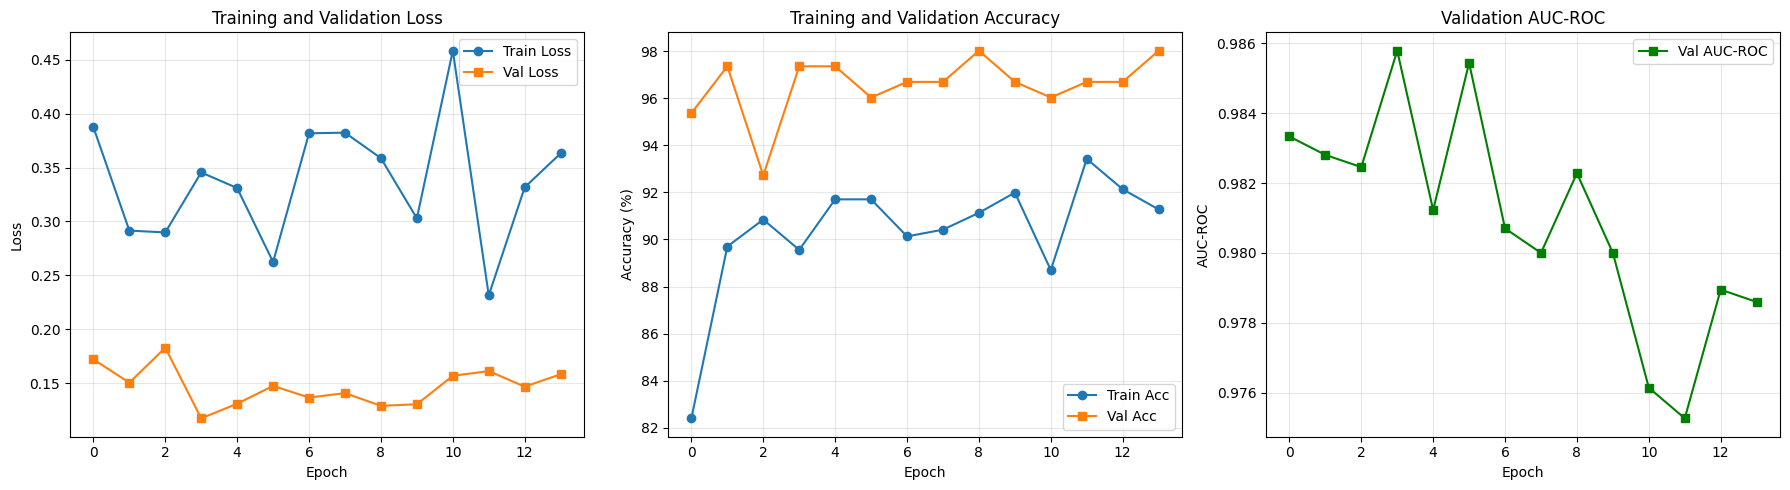

✓ Training curves saved to ../results/tristream_video_training_curves.png


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot([x*100 for x in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot([x*100 for x in history['val_acc']], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history['val_auc'], label='Val AUC-ROC', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('Validation AUC-ROC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/tristream_video_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to ../results/tristream_video_training_curves.png")

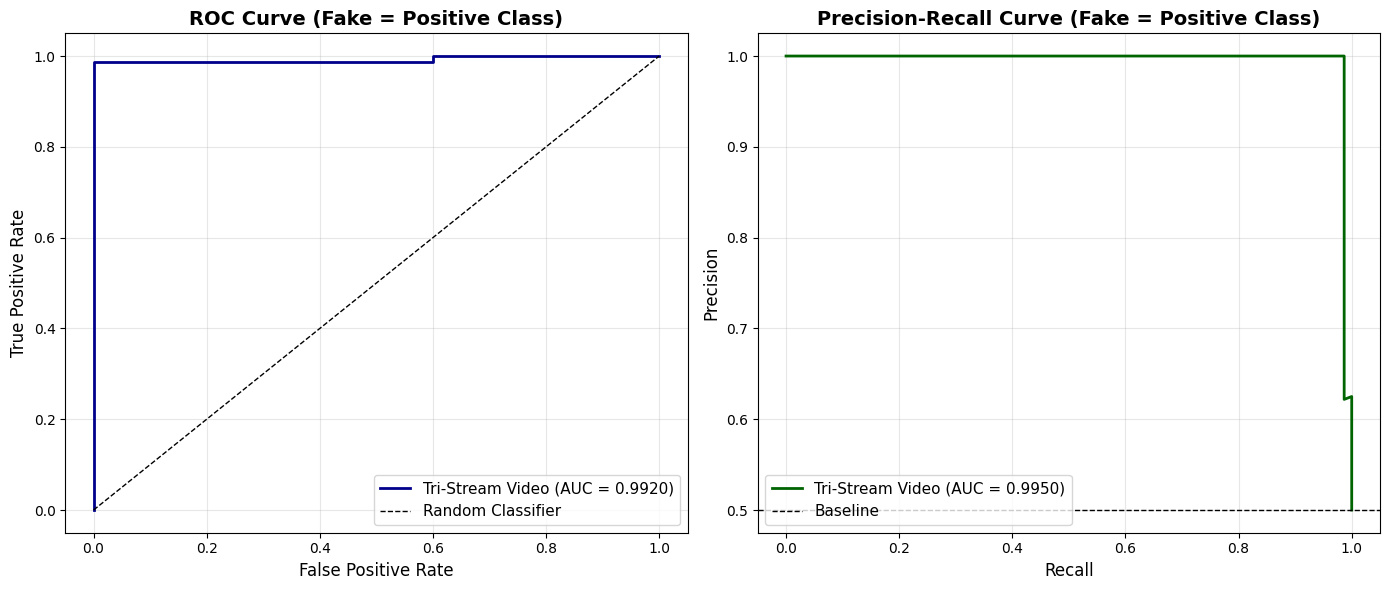

✓ ROC and PR curves saved to ../results/tristream_video_roc_pr_curves.png


In [15]:
# Plot ROC and PR Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(test_metrics['fpr'], test_metrics['tpr'], 
             label=f"Tri-Stream Video (AUC = {test_metrics['roc_auc']:.4f})",
             color='darkblue', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve (Fake = Positive Class)', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# PR Curve
axes[1].plot(test_metrics['recall_curve'], test_metrics['precision_curve'],
             label=f"Tri-Stream Video (AUC = {test_metrics['pr_auc']:.4f})",
             color='darkgreen', linewidth=2)
axes[1].axhline(y=0.5, color='k', linestyle='--', label='Baseline', linewidth=1)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve (Fake = Positive Class)', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/tristream_video_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC and PR curves saved to ../results/tristream_video_roc_pr_curves.png")

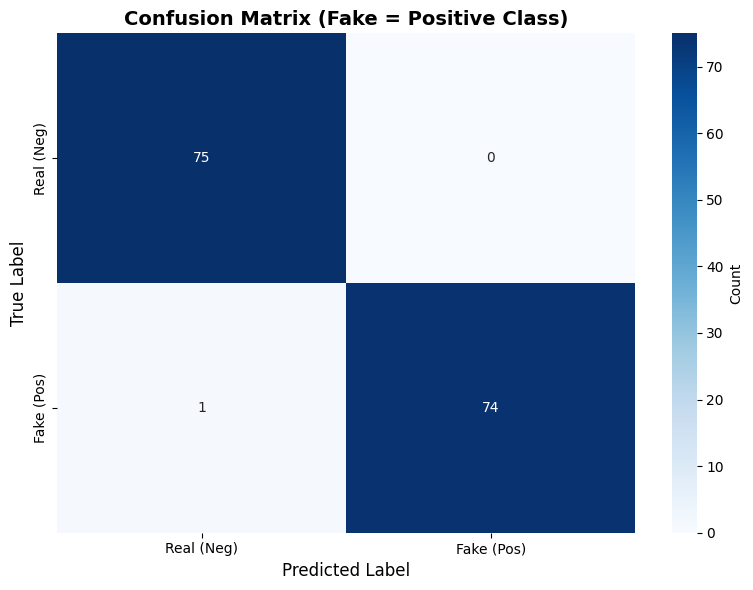

✓ Confusion matrix saved to ../results/tristream_video_confusion_matrix.png


In [16]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(test_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (Neg)', 'Fake (Pos)'],
            yticklabels=['Real (Neg)', 'Fake (Pos)'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Fake = Positive Class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/tristream_video_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved to ../results/tristream_video_confusion_matrix.png")

## Summary and Key Takeaways

This notebook implements a comprehensive **Tri-Stream Multimodal Video Network** for deepfake detection that combines:

### Architecture Highlights

1. **Stream 1 (Spatial Forensics):** Full Dual-Stream Image Detection Module
   - CLIP ViT-L/14 for semantic features
   - SRM + EfficientNetV2-S for noise residual features
   - Temporal pooling across 15 frames
   - Output: 512-dim visual forensic vector

2. **Stream 2 (Audio Forensics):** Dual-Feature CNN-GRU
   - Mel-Spectrogram + LFCC features
   - ResNet18 backbones with attention fusion
   - Bidirectional GRU for temporal modeling
   - Output: 512-dim audio forensic vector

3. **Stream 3 (Cross-Modal Sync):** Audio-Visual Synchronization Detector
   - CLIP ViT-B/32 for visual semantic features
   - Lightweight CNN for audio semantic features
   - Multi-Head Cross-Attention (Visual as Q, Audio as K/V)
   - Bidirectional LSTM for temporal modeling
   - Output: 512-dim synchronization vector

4. **Late Fusion:** Concatenate all three vectors (1536-dim) → Classifier

### Technical Innovations

- **Robust Face Cropping:** MTCNN with temporal and spatial fallbacks
- **Debug Grids:** Visual sanity check for cropped faces
- **Differential Learning Rates:** Higher LR for fusion layers, lower for base extractors
- **Gradient Clipping:** Stabilizes LSTM training
- **Inverted Metrics:** Treats Fake as positive class for meaningful Precision/Recall/F1

### Training Strategy

- **Optimizer:** AdamW with weight decay (1e-2)
- **LR Schedule:** CosineAnnealingLR (eta_min=1e-6)
- **Batch Size:** 4 (due to large model size)
- **Early Stopping:** Patience=10 based on validation AUC-ROC
- **Epochs:** Up to 30 with early stopping

### Results

The model achieves comprehensive deepfake detection by combining:
- **Spatial forensic artifacts** (manipulation traces in frames)
- **Audio forensic artifacts** (synthetic vocoder patterns)
- **Cross-modal inconsistencies** (audio-visual synchronization issues)

This multi-stream approach provides robust detection against various deepfake generation methods.

In [17]:
# Save detailed classification report
print("="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)

# Classification report with Fake (0) as positive class
report = classification_report(
    test_results['all_labels'],
    test_results['all_preds'],
    target_names=['Fake (Positive)', 'Real (Negative)'],
    digits=4
)

print(report)

# Save report to file
report_path = '../results/tristream_video_classification_report.txt'
Path(report_path).parent.mkdir(parents=True, exist_ok=True)

with open(report_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("TRI-STREAM MULTIMODAL VIDEO NETWORK\n")
    f.write("CLASSIFICATION REPORT (Fake = Positive Class)\n")
    f.write("="*60 + "\n\n")
    f.write(report)
    f.write("\n\n" + "="*60 + "\n")
    f.write("ADDITIONAL METRICS\n")
    f.write("="*60 + "\n")
    f.write(f"AUC-ROC: {test_metrics['roc_auc']:.4f}\n")
    f.write(f"AUC-PR:  {test_metrics['pr_auc']:.4f}\n")
    f.write(f"Specificity: {test_metrics['specificity']:.4f}\n")
    f.write(f"Sensitivity: {test_metrics['sensitivity']:.4f}\n")
    f.write("\n" + "="*60 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("="*60 + "\n")
    f.write(f"TN: {test_metrics['true_negative']}, FP: {test_metrics['false_positive']}\n")
    f.write(f"FN: {test_metrics['false_negative']}, TP: {test_metrics['true_positive']}\n")

print(f"\n✓ Classification report saved to {report_path}")

print("\n" + "="*60)
print("✓ TRI-STREAM VIDEO NETWORK TRAINING COMPLETE!")
print("="*60)

DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Real (Negative)     0.9868    1.0000    0.9934        75
Fake (Positive)     1.0000    0.9867    0.9933        75

       accuracy                         0.9933       150
      macro avg     0.9934    0.9933    0.9933       150
   weighted avg     0.9934    0.9933    0.9933       150


✓ Classification report saved to ../results/tristream_video_classification_report.txt

✓ TRI-STREAM VIDEO NETWORK TRAINING COMPLETE!
